
<h1><center>Lab 1 - A1</center></h1>

##	REQUIREMENTS
1.	Source code (notebook) needs to be documented.
2.	Algorithms have to be tested for several parameter values (sufficient to clearly determine performance).
3.	Experiments must be performed for all available problem instances and results compared for diferent parameter settings.
4.	Results of the experiments need to be saved in output files, indicating solution quality, parameter values used, number of runs.
5.	A report should capture the following: problem definition, algorithm used (name, steps/pseudocode), parameter setting, comparative results of experiments, discussion of results.


## Knapsack Problem
- $n$ objects, each has a value ($v$) and a weight ($w$)
- Objective: the knapsack to contain max value without exceeding max weight $W$
 - $x_i=1$ means object $i$ is selected
 - $x_i=0$ means object $j$ is not selected

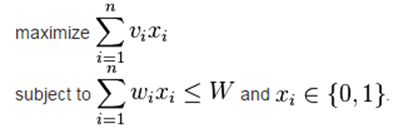


## WORK DURING THE LAB
1.	Exhaustive search: generate all possible binary strings of size N and print them on the screen. Test the code for different values of N.
2.	Read data for the knapsack problem.
3.	Generate a random solution for the knapsack problem and verify its quality.

**Points for the work during the lab: 25p**


In [1]:
# exhaustive search
def generate_binary_strings(n: int) -> list:
    results = []
    
    def backtrack(current_combo):
        if len(current_combo) == n:
            results.append(tuple(current_combo))
            return
        
        backtrack(current_combo + [0])
        
        backtrack(current_combo + [1])
        
    backtrack([])
    return results

N = 3
binary_combinations = generate_binary_strings(N)

print(f"All possible solutions for N={N}:")
for combo in binary_combinations:
    print(combo)

All possible solutions for N=3:
(0, 0, 0)
(0, 0, 1)
(0, 1, 0)
(0, 1, 1)
(1, 0, 0)
(1, 0, 1)
(1, 1, 0)
(1, 1, 1)


In [2]:
def load_data(file_name: str) -> "list[tuple[int, int]]":
  weights_and_values = []
  max_W = 0
  try:
    with open(file_name, 'r') as f:
      lines = [line.strip() for line in f.readlines() if line.strip()]
      n = int(lines[0])

      for i in range (1,n+1):
          parts = lines[i].split()
          weight = int(parts[1])
          value = int(parts[2])
          weights_and_values.append((weight,value))

      max_W = int(lines[n+1])

  except FileNotFoundError:
        print(f"Error: Could not find the file '{file_name}'.")
  except IndexError:
        print("Error: The file format doesn't match the expected structure.")
  except Exception as e:
        print(f"An unexpected error occurred: {e}")
  return weights_and_values,max_W

items,max_W = load_data('knapsack-20.txt')
n = len(items)
print(max_W)

524


In [3]:
def verify_quality(solution: list, items: list, W: int) -> int:
    total_weight = 0
    total_value = 0
    n = len(solution)
    
    for i in range(n):
        x_i = solution[i]
        
        if x_i == 1:
            w_i = items[i][0] 
            v_i = items[i][1] 
            
            total_weight += w_i
            total_value += v_i
            
    if total_weight > W:
        return 0
        
    return total_value

In [4]:
import random

def generate_random_solution(n: int) -> list:
    return [random.randint(0, 1) for _ in range(n)]

random_sol = generate_random_solution(n)
quality_score = verify_quality(random_sol, items, max_W)
print(f"Solution: {random_sol}, Quality Score: {quality_score}")
#print(f"Quality Score: {quality_score}")

Solution: [0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1], Quality Score: 0


##	ASSIGNMENT A1
1.	Implement a random search method for the knapsack problem.
 1.	From k random solutions, the method should return the best one.
 1.	Test the method for different values of k.
 1.	Perform experiments for knapsack instances of size 20 and 200.
1.	Submit source code and report.

**Deadline to submit A1: Lab 2**
**Points for A1: 25p**


In [ ]:
def random_search(k: int, items: list, W: int) -> tuple:
    """
    Generates k random solutions and returns the best valid one.
    """
    n = len(items)
    best_solution = None
    best_value = -1 
    
    for _ in range(k):
        current_solution = generate_random_solution(n)
        
        current_value = verify_quality(current_solution, items, W)
        
        if current_value > best_value:
            best_value = current_value
            best_solution = current_solution
            
    return best_solution, best_value

In [8]:
import time

def run_experiments(instance_file: str, k_values: list, num_runs: int = 5):
    """
    Runs experiments for different k values and saves results to a file.
    """
    items, W = load_data(instance_file)
    n = len(items)
    
    output_filename = f"results_n{n}.txt"
    
    with open(output_filename, 'w') as f:
        f.write(f"--- Experiment Results for {instance_file} (n={n}, W={W}) ---\n")
        
        for k in k_values:
            f.write(f"\nTesting k = {k} ({num_runs} runs)\n")
            f.write("-" * 30 + "\n")
            
            total_quality = 0
            
            for run in range(num_runs):
                start_time = time.time()
                
                best_sol, best_val = random_search(k, items, W)
                
                end_time = time.time()
                elapsed = end_time - start_time
                
                total_quality += best_val
                
                f.write(f"Run {run + 1}: Quality = {best_val}, Time = {elapsed:.4f}s\n")
            
            avg_quality = total_quality / num_runs
            f.write(f">> Average Quality for k={k}: {avg_quality:.2f}\n")
            
    print(f"Experiments finished for {instance_file}! Results saved to {output_filename}")

k_test_values = [10, 100, 1000, 10000]

run_experiments('knapsack-20.txt', k_test_values, num_runs=100)


Experiments finished for knapsack-20.txt! Results saved to results_n20.txt


## 1. Algorithm Used: Random Search
To solve this problem, we implemented a Random Search method. This is a basic search algorithm that relies purely on random sampling of the search space rather than exploring it systematically.

The logic is driven by our core implementation: the algorithm executes a loop `for _ in range(k):` to generate *k* independent random solutions. For each iteration, a random binary array is generated using the `generate_random_solution(n)` function. The fitness and feasibility of each array are then evaluated using the `verify_quality(current_solution, items, W)` function, which returns 0 if the weight constraint is violated, or the total value if the solution is valid. The algorithm tracks the highest valid quality score across all *k* iterations and returns the best solution found.

## 2. Parameter Settings
To observe the behavior of the Random Search algorithm, the following experimental parameters were established:
* **Problem Instances (n):** Tested on two different knapsack sizes: n = 20 items and n = 200 items.
* **Number of Iterations (k):** Tested across four magnitudes to observe scaling performance: k = 10, 100, 1000, and 10000.
* **Number of Runs:** For each configuration of n and k, the experiment was executed 5 independent times to account for the random nature of the algorithm and to calculate an average expected quality.

## 3. Comparative Results of Experiments

### Instance Size: n = 20
*(Search Space: approx. 1 million possible combinations)*

| Parameter (k) | Run 1 Value | Run 2 Value | Run 3 Value | Run 4 Value | Run 5 Value | **Average Quality** |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| k = 10 | 512 | 579 | 522 | 531 | 490 | **526.80** |
| k = 100 | 628 | 648 | 718 | 667 | 689 | **670.00** |
| k = 1000 | 681 | 708 | 727 | 704 | 709 | **705.80** |
| k = 10000 | 739 | 755 | 739 | 770 | 763 | **753.20** |

### Instance Size: n = 200
*(Search Space: approx. 1.6e60 possible combinations)*

| Parameter (k) | Run 1 Value | Run 2 Value | Run 3 Value | Run 4 Value | Run 5 Value | **Average Quality** |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| k = 10 | 0 | 0 | 94640 | 0 | 0 | **18928.00** |
| k = 100 | 96060 | 95968 | 95486 | 95014 | 93489 | **95203.40** |
| k = 1000 | 96019 | 96357 | 96321 | 96263 | 96149 | **96221.80** |
| k = 10000 | 97224 | 96856 | 97161 | 96748 | 97218 | **97041.40** |

## 4. Discussion of Results

**Impact of Parameter k:**
As demonstrated in the results tables, there is a direct correlation between the number of generated solutions (k) and the average quality of the final solution. For both problem instances, increasing k from 10 to 10000 reliably improves the best-found value. Because Random Search relies entirely on chance, generating more solutions directly increases the probability of encountering a combination with a highly favorable weight-to-value ratio.

**Impact of Problem Size (n):**
The experiments clearly highlight the limitations of Random Search when scaling up. 
* For n = 20, the total search space is roughly 1 million possible combinations. A run of k = 10000 evaluates about 1% of the entire search space, making it highly likely to find a near-optimal solution. 
* However, for n = 200, the search space explodes. Here, k = 10000 evaluates an infinitesimally small fraction of the possibilities. Consequently, the quality of the solutions found for n = 200 is likely very far from the true global optimum. The Random Search algorithm frequently generates infeasible solutions when n is large, meaning many of the iterations are effectively wasted on invalid states. This is clearly visible in the k = 10 results, where 4 out of 5 runs returned a quality of 0 (all generated solutions were infeasible), and only one lucky run found a valid solution worth 94640.